# Predicting Player Contributions to PLAICraft with Experience and Age

## Introduction 335 words

PLAICraft is a research data collection project that uses the video game "Minecraft" to collect detailed gameplay information such as played hours on participants and their demographic information such as age, experience, and gender. This information is provided in the `players.csv` file, which we will refer to as the `players` dataset.

Research data collection projects like PLAICraft need large amounts of data to have meaningful results, and so the team needs to be able to recruit participants that will contribute large amounts of data. Players that play more are able to provide more data for research. With that goal in mind, we investigated the second question: "Which 'kinds' of players are most likely to contribute a large amount of data?".

Specifically, based on the demographic data available to us, our question became **can the Age and experience of a player be used to predict the sum total of hours played across multiple sessions of PLAICraft?**

Since the research team is looking for 'kinds' of players, we include Age as demographic information. As we will discuss, we decided against including gender because the data is lacking in many observations for most non-male genders, and so we don't have sufficient training data to use it as a predictor. Experience is the one additional detail for 'type' of player, and we convert it from 5 discrete factors into a linear scale of 1-5 in the order Amateur, Beginner, Regular, Veteran, and Pro. We use a linear scale instead of categories so we can take advantage of that fact that an Amateur and Beginner are a more similar 'type' of player than an Amateur and a Pro, a relationship that our model couldn't take into account if we treated experience as a factor.

The researchers are asking to identify predictors for players who contribute a "large amount" of data which could be considered categorical, but we plan to treat it as a regression problem where we predict the numerical value of played_hours for a given type of player. This gives the researchers the ability to define their own cutoff for what minimum number of hours is considered 'large'.

In [1]:
library(tidyverse)
library(lubridate)
library(tidymodels)

players_data = download.file("https://github.com/apepers/DSCI_100_009_33/raw/refs/heads/main/players.csv", "players.csv")
players = read_csv("players.csv")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──

✔ broom        1.0.6     ✔ rsample      1.2.1
✔ dials        1.3.0     ✔ tune         1.1.2
✔ infer        1.0.7     ✔ workflows    1.1.4
✔ modeldata    1.4.0     ✔ workflowsets 1.0.1
✔ parsnip      1.2.1     ✔ yardstick    1.3.1
✔ recipes      1.1.0     

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filt

## Methods & Results About 1000 words

- describe the methods you used to perform your analysis from beginning to end that narrates the analysis code.
- your report should include code which:
    - loads data
    - wrangles and cleans the data to the format necessary for the planned analysis
    - performs a summary of the data set that is relevant for exploratory data analysis related to the planned analysis
    - creates a visualization of the dataset that is relevant for exploratory data analysis related to the planned analysis
    - performs the data analysis
    - creates a visualization of the analysis
    - note: all figures should have a figure number and a legend

Our first step was to load, tidy, and perform exploratory visualizations with the dataset provided by the PLAICraft researchers.

In [2]:
# Load dataset
players_data = download.file("https://github.com/apepers/DSCI_100_009_33/raw/refs/heads/main/players.csv", "players.csv")
players = read_csv("players.csv")
head(players)

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21
Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17


#### Summary of Dataset
`players.csv` includes information about each player, with 7 variables:

|Variable|Type|Description|
|-----------|-------|------------|
|experience|character|The player's experience level|
|subscribe|logical|If the player is subscribed to a game-related newsletter|
|hashedEmail|character|Unique hashed email of player|
|played_hours|double|Hours player has played|
|name|character|First name of player|
|gender|character|Gender of player|
|Age|double|Age of player (years)|

In [3]:
obsPlayers <- summarize(players, count = n()) |> pull(count)
print(paste("Number of Observations in Players:", obsPlayers))

[1] "Number of Observations in Players: 196"


In [4]:
summarizedPlayers <- summary(players)
summarizedPlayers

  experience        subscribe       hashedEmail         played_hours    
 Length:196         Mode :logical   Length:196         Min.   :  0.000  
 Class :character   FALSE:52        Class :character   1st Qu.:  0.000  
 Mode  :character   TRUE :144       Mode  :character   Median :  0.100  
                                                       Mean   :  5.846  
                                                       3rd Qu.:  0.600  
                                                       Max.   :223.100  
                                                                        
     name              gender               Age       
 Length:196         Length:196         Min.   : 9.00  
 Class :character   Class :character   1st Qu.:17.00  
 Mode  :character   Mode  :character   Median :19.00  
                                       Mean   :21.14  
                                       3rd Qu.:22.75  
                                       Max.   :58.00  
                               

Some initial observations we made from the data for players:
- Most players have very few played hours (a median of 0.1 hours, and even up to the 3rd quartile we're only at 0.6 hours), and a lot have 0 (at least the full lowest 25%, based on the 1st quartile.)
- We have at least one entry with an unusually large played hours of 223, from the reported max.
- The players are usually young, with many under 20 years old (based on a mean of 21.14, and 3rd quartile of 22.75 years.)
- The Age variable has two NA's we'll need to deal with, but otherwise data is already tidy and ready to work with.

We identified Age, experience, and gender as all potential demographic data.

In [5]:
gender_distribution = players |>
        group_by(as_factor(gender)) |>
        summarize(n = n())

gender_distribution

as_factor(gender),n
<fct>,<int>
Male,124
Female,37
Non-binary,15
Prefer not to say,11
Agender,2
Two-Spirited,6
Other,1


Examining the gender variable, we identified that the majority of observations are from players who identified as Male, while the rest are split over several gender identities. Due to the uneven distribution of genders in this dataset, compounded by other limitations in useable observations that we will touch on shortly, we decided to leave gender out of our model in this report.

In [6]:
players <- mutate(players, experience_level = as.numeric(factor(experience, levels = c("Amateur", "Beginner", "Regular", "Veteran", "Pro"))))
head(players)

experience,subscribe,hashedEmail,played_hours,name,gender,Age,experience_level
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9,5
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17,4
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17,4
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21,1
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21,3
Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17,1


Finally we observed that while experience could be treated as a factor, doing so would miss out on the relationships implied by what the variable represents. An 'Amateur' and 'Beginner' player are more similar in demographic than an 'Amateur' and 'Veteran' player, and so to capture that relationship, we converted the experience into a linear scale from 1-5.

We set up this scale in the ascending order of Amateur, Beginner, Regular, Veteran, and Pro. We did not have access to information on whether this is the order intended by the researchers, so that is a point for future clarification in providing this model.

### Exploratory Data Analysis

For our exploratory visualizations we focused on our identified demographic information of Age and experience.

#### Age

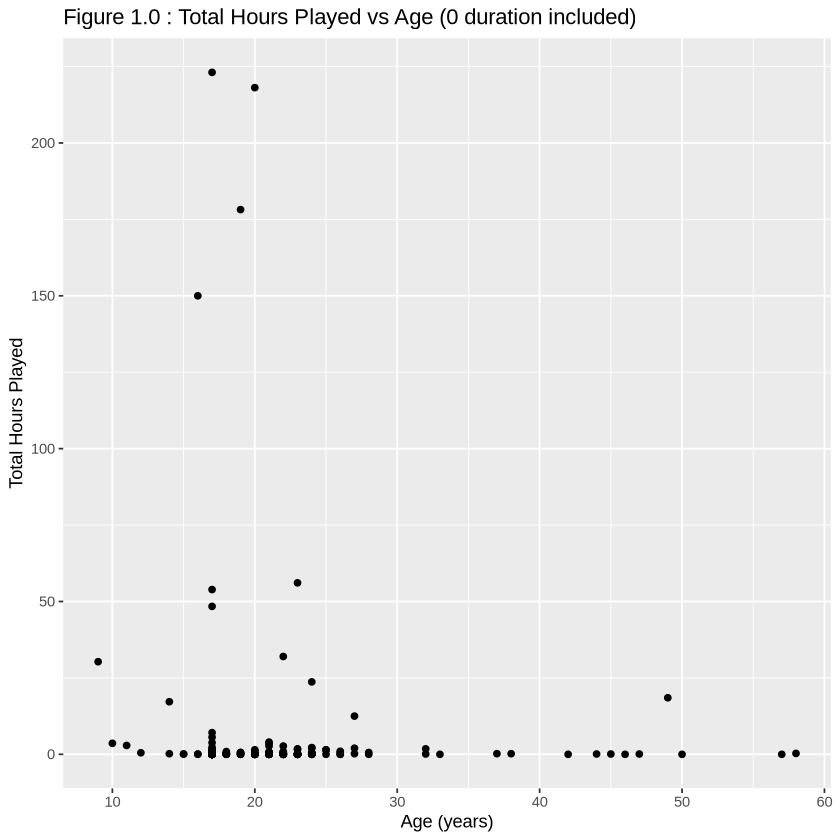

In [7]:
# First explore the Age and hours played relationship with a scatterplot
age_time_plot = players |>
    ggplot(aes(x = Age, y = played_hours)) +
    geom_point(na.rm = TRUE) +
    labs(x = "Age (years)", y = "Total Hours Played") +
    ggtitle("Figure 1.0 : Total Hours Played vs Age (0 duration included)")

age_time_plot

As we'll discuss in more detail later, once we started visualizing the player data is becomes even clearer that it includes many players with 0 hours played, as well as a few outliers with over 100 hours played. To get a better view of the relationship between Age and played_hours among players who did play, we filter out the players with no hours, and switch to a logarithmic scale.

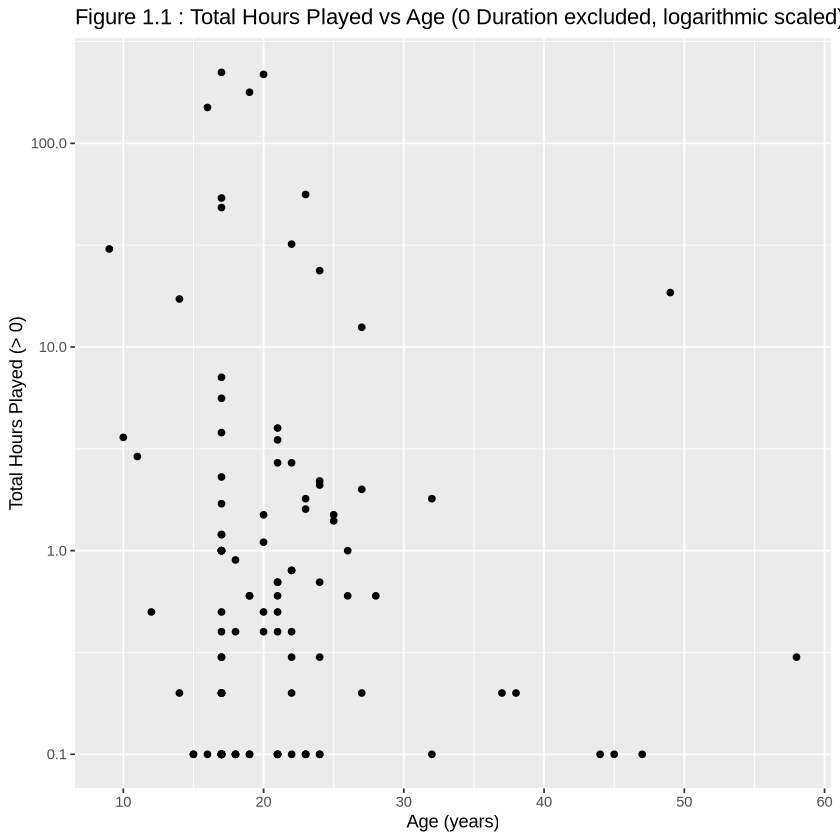

In [8]:
age_time_plot_no_0 = players |>
    filter(played_hours > 0) |>
    ggplot(aes(x = Age, y = played_hours)) +
    geom_point(na.rm = TRUE) +
    labs(x = "Age (years)", y = "Total Hours Played (> 0)") +
    ggtitle("Figure 1.1 : Total Hours Played vs Age (0 Duration excluded, logarithmic scaled)") +
    scale_y_log10()

age_time_plot_no_0

From this exploratory visualization we do not see any clear trend suggesting a relationship between Age and total hours played. We see a wide variety of responses for players in their teens and early 20s, and relatively few observations from older players, making conclusions difficult. But since this is one of the few pieces of demographic data we do have, we decided to continue with including it in our data, in hopes there are some non-obvious patterns when combined with experience.

#### Experience level

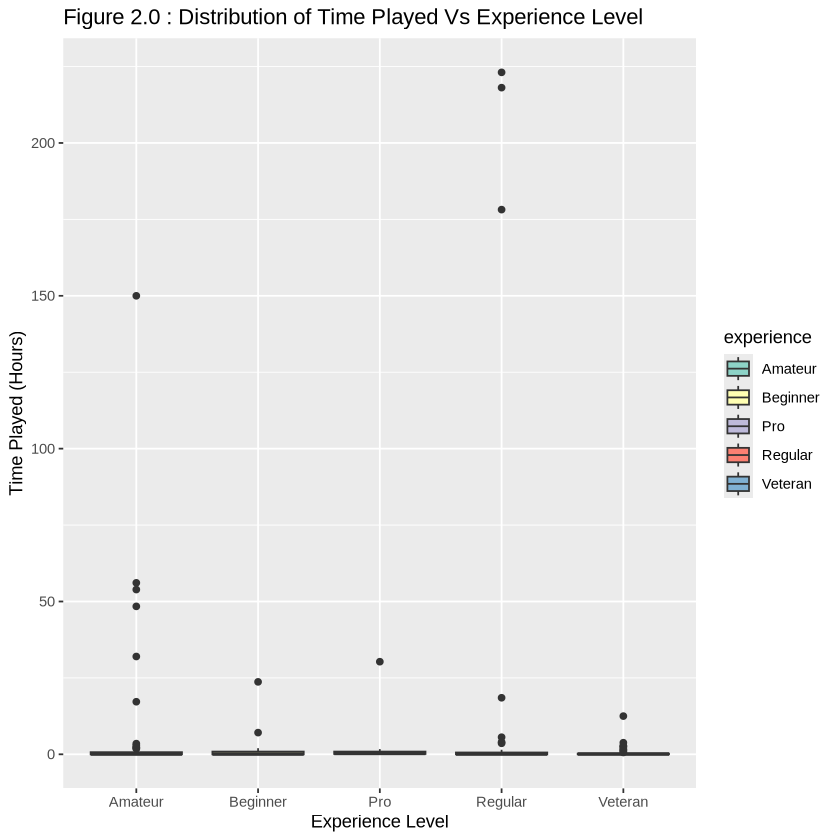

In [9]:
# Second explore the Experience Level and hours played relationship with a boxplot
Distribuition_plot_0<-ggplot(players, aes(x = experience, y = played_hours, fill = experience)) +
geom_boxplot() +
labs(title = "Figure 2.0 : Distribution of Time Played Vs Experience Level",
    x = "Experience Level",
    y = "Time Played (Hours)")+
scale_fill_brewer(palette = "Set3")
Distribuition_plot_0

This graph includes all zero-hour playtime which shows the full pattern that many players, regardless of experience level, did not contribute large amounts of data to the server. This is evident in the highly compressed y-axis values due to the large number of zero-hour players in each experience level. Only a small number of outliers in each group contributed large amounts game play, which means that high engagement is rare in any experience level.

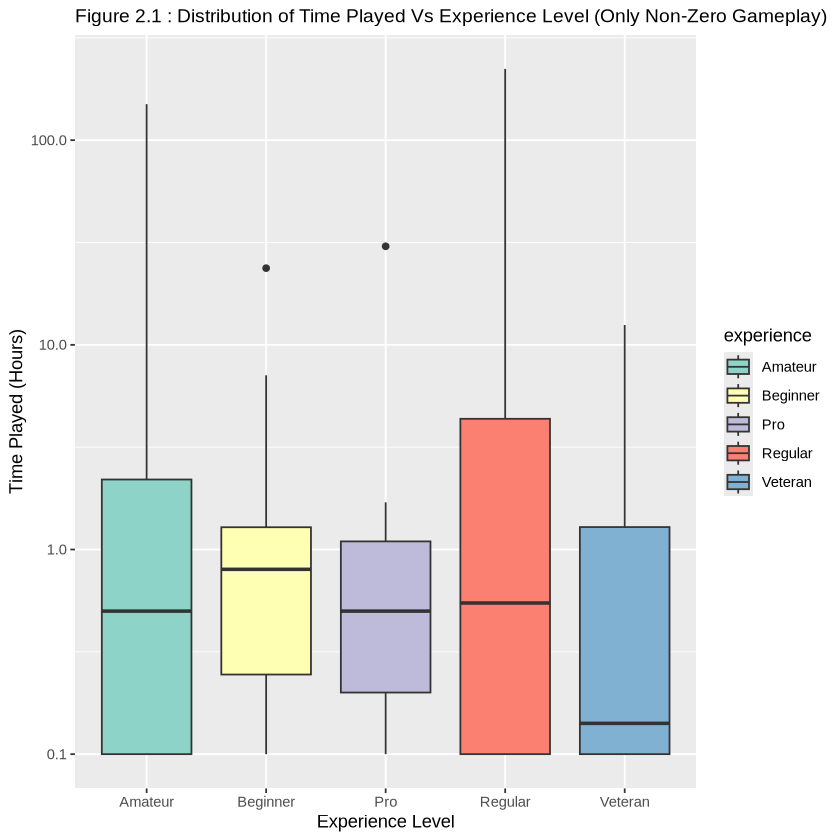

In [10]:
Distribuition_plot_no_0<-players|>
 filter(played_hours > 0) |>  #filtering out zero hours played
ggplot(aes(x = experience, y = played_hours, fill = experience)) +
  geom_boxplot() +
  labs(title = "Figure 2.1 : Distribution of Time Played Vs Experience Level (Only Non-Zero Gameplay)",
    x = "Experience Level",
    y = "Time Played (Hours)") +
 scale_y_log10() + #log10 cannot display 0 values, this helps visualize the non-zero distribuition better
scale_fill_brewer(palette = "Set3") +
 theme(plot.title = element_text(size = 11.5))
Distribuition_plot_no_0

However, this plot with only non-zero hours helps focus in on the patterns amongst the players who did contribute data. It also allows for meaningful comparison across experience levels and helps identify which player groups will play longer and therefore, contribute more data to the server. In this graph, there are differences in playtime across experience levels with Regular and Amateur's having a higher median playtime and larger variability in comparison to the Beginners, Pros, and Veterans.

### Creating a Model with knn Regression

Our goal is to predict played_hours, a non-categorical variable, and so our next step was to create a model with K nearest neighbour regression using *Age* and *experience* as predictor variables and *played_hours* as the responsible variable. The relationship between these variables doesn't seem linear and so we choose K nearest neighbour for its flexibility modelling non-linear relationships. One downside is that if the researchers do succeed in collecting a much larger dataset, this method will become slow.

Warning message:
“tune samples were requested but there were 145 rows in the data. 140 will be used.”


[1] "Best value of N:  5"


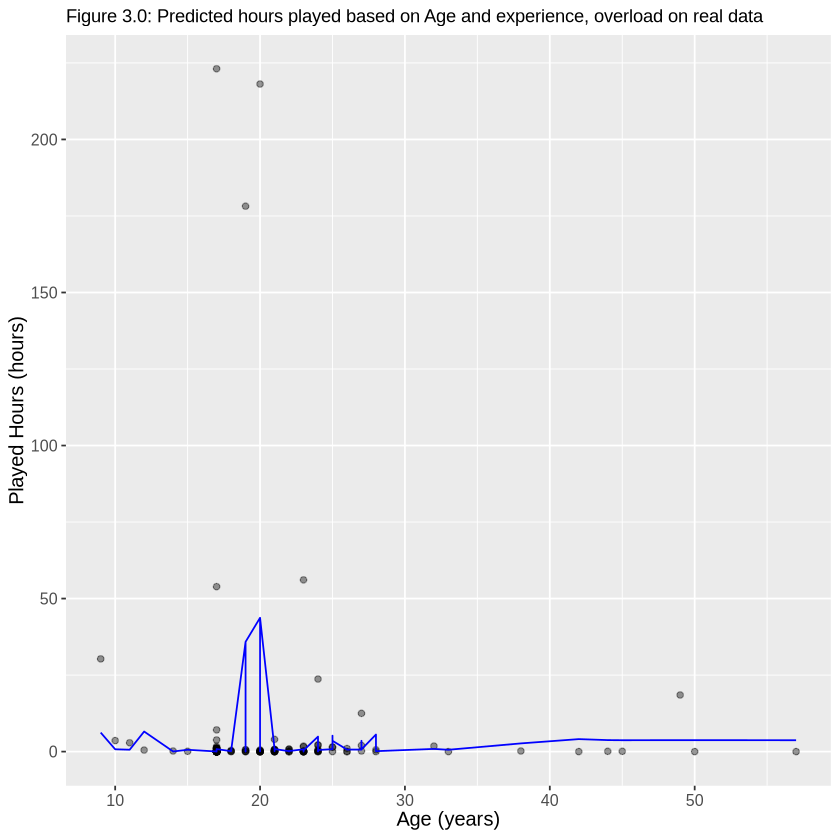

[1] "RMSPE of model:  23.9227779766993"


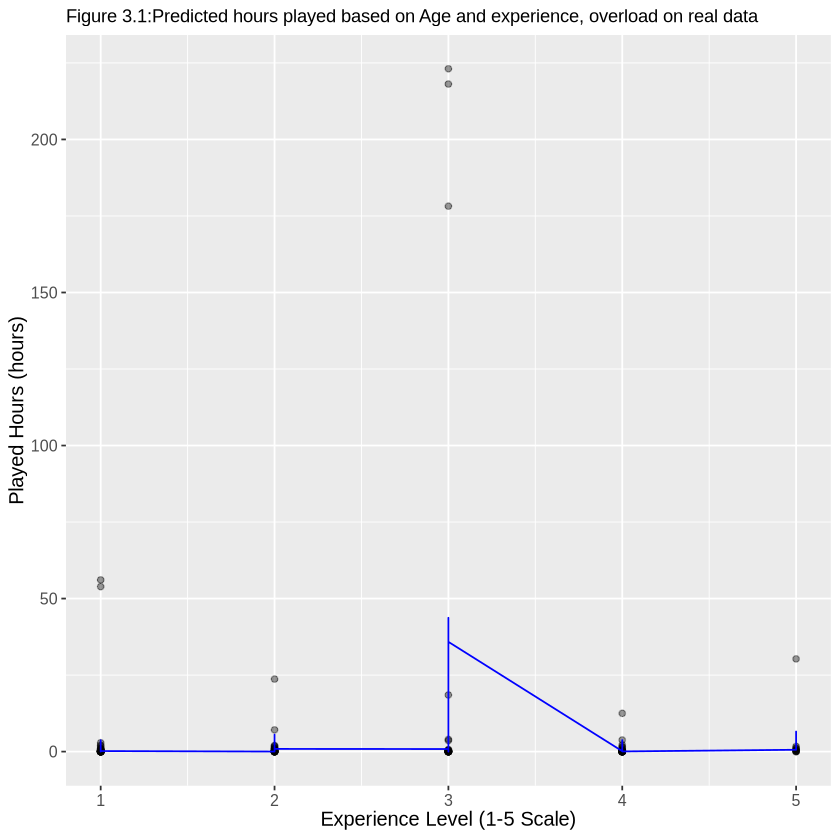

In [11]:
# Set a seed, so this code is reproducable
set.seed(100)

# Reduce player dataset to relevant variables, filter out NAs from Age
players_adjusted = players |>
    select(Age, experience_level, played_hours) |>
    filter(!is.na(Age))

# Make our split of training/testing data
player_split = initial_split(players_adjusted, prop = 0.75, strata = played_hours)
player_training <- training(player_split)
player_testing <- testing(player_split)

# First tuning round of knn to find best count of neighbours
player_spec <- nearest_neighbor(weight_func = "rectangular",
                              neighbors = tune()) |>
            set_engine("kknn") |>
            set_mode("regression")

# scale step necessary since Age is bigger range of numbers than experience
player_recipe <- recipe(played_hours ~ Age + experience_level, data = player_training) |>
    step_center(all_predictors()) |>
    step_scale(all_predictors())

players_vfold <- vfold_cv(player_training, v = 5, strata = played_hours)

player_fit <- workflow() |>
            add_recipe(player_recipe) |>
            add_model(player_spec) |>
            fit(data = player_training)

# test N from 1 to 50
gridvals <- tibble(neighbors = seq(from = 1, to = 50, by = 1))

player_results <- player_fit |>
  tune_grid(resamples = players_vfold, grid = gridvals) |>
  collect_metrics() |>
  filter(.metric == "rmse")

# print the N with the best rmse
k_min <- player_results |>
  filter(mean == min(mean)) |>
    pull(n)

print(paste("Best value of N: ", as.numeric(k_min)))

# Now do it again but using that N we just figured out
minimized_spec <- nearest_neighbor(weight_func = "rectangular",
                              neighbors = k_min) |>
            set_engine("kknn") |>
            set_mode("regression")

player_workflow <- workflow() |>
            add_recipe(player_recipe) |>
            add_model(minimized_spec) |>
            fit(data = player_training)

# Do predictions on the training data
player_preds <- player_workflow |>
  predict(player_training) |>
  bind_cols(player_training)

# Visualize the prediction line on top of the actual data points
played_hour_predictions <- player_preds |>
    ggplot(aes(x = Age, y = played_hours)) +
        geom_point(alpha = 0.4) +
        geom_line(
            mapping = aes(x = Age, y = .pred), 
            color = "blue") +
        xlab("Age (years)") +
        ylab("Played Hours (hours)") +
        ggtitle("Figure 3.0: Predicted hours played based on Age and experience, overload on real data") +
        theme(text = element_text(size = 12), plot.title = element_text(size = 11))

played_hour_predictions

played_hour_predictions_experience <- player_preds |>
    ggplot(aes(x = experience_level, y = played_hours)) +
        geom_point(alpha = 0.4) +
        geom_line(
            mapping = aes(x = experience_level, y = .pred), 
            color = "blue") +
        xlab("Experience Level (1-5 Scale)") +
        ylab("Played Hours (hours)") +
        ggtitle("Figure 3.1:Predicted hours played based on Age and experience, overload on real data") +
        theme(text = element_text(size = 12), plot.title = element_text(size = 11))

played_hour_predictions_experience

# Calculate the output the rmspe of the final model
test_results <- player_workflow |>
                    predict(player_testing) |>
                    bind_cols(player_testing) |>
                    metrics(truth = played_hours, estimate = .pred)                    

rmspe <- test_results |>
                filter(.metric == 'rmse') |>
                select(.estimate) |>
                pull()

print(paste("RMSPE of model: ", rmspe))

Figure 3.0 (Age on x-axis)
The grey points reveal each player's actual hours played on the server, plotted against their age. The KNN model's predicted amount of gameplay hours based on their age is shown with the blue line. The line stays mostly focused around zero with a spike in late teens to early twenties.

Figure 3.1 (Experience level on x-axis)
The grey points again show the  player's real hours played, but now grouped by experience level. The blue line shows the model's predicted hours for each experience level. The line once again stays mostly focused around zero with a small spike around experience level 3(Regular). Where the scale is 1-5 Amateur, Beginner, Regular, Veteran, and Pro respectively.

Our knn regression model has a RMSE of 23.92 hours. This suggests that it's predictions for how many total hours a player with given demographic type will contribue to the project will have an error of about 23.92 hours. This is not a good result, as the vast majority of observations have values less than 20 hours, and so we know the difference between a player who contributes 0 hours and 20 hours is significant in the context of this research project.

The fact that our model does a poor job making confident predictions is not a surprise to us, because we've already discussed the very uneven distribution of hours played within the dataset. Without many examples of players who contributed more than a small amount of data, and with so many observations from players who did not contribute at all, we're not left with many data points to find a pattern within.

## Discussion About 500 words rn

Ultimately our finding was that we were unable to use the player data available to create a very effective regression model to predict played hours based on demographic. We can observe some potential patterns based on our visualizations of the model predictions over the range of possible demographic values.

The game is mostly popular among younger age groups. People aged between 10 and 30 tend to play for a longer time in our model, and there are also more players in that range within our dataset. It also appears that players with a moderate amount of experience with Minecraft, who report themselves as a 'Regular', are most likely to contribute a larger amount of data.

These findings are in line with what we would expect, as younger people are likely to have more time to spend on a game project like this than older adults. It also seems reasonable that players who are already familar with Minecraft are more likely to play an experimental version of it like PLAICraft, and since they already like the game enough to have played it regularly, will be willing to put more hours into playing it within this project.

However ultimately the very large RMSE of our model gives us a low amount of confidence in our predictions. In order to build a more effective model and look for trends in future data, our recommendations would be for the research team to attempt and improve several issues with the data:

#### Collect a larger quantity of observations from players who put a moderate amount of time into the project. 
In this set the amount of observations that could reasonably be considered a "large" amount of hours played is very small, making it difficult to identify any trends. We recognize that the research team has already identified that they want to seek our players who contribute more play time which was the reason for their interest in this type of analysis, but our findings suggest that asking for what "type" of player contributes the most data may be premature at this stage. If the research team cannot collect more data from specifically players that put in larger number of hours, they may need to simply collect a larger amount of data overall, and hope that trends become more visible as the population size grows.

#### Collect additional demographic information, or expand the representation within existing demographics. 
The lack of non-zero observations for non-male genders made us decide not to include gender as an additional piece of demographic information. If the researchers want to make better use of gender as a piece of demographic information they should make an effort to collect data from more non-male players, so that there is sufficient data to examine for trends.

Similar issues were present in the Age data, where since the distribution is very skewed towards younger players, it is difficult to determine whether the model's association between lower ages and higher play times represents an actual relationship, or if it's simply due to the relative lack of data available for older players.

Summarize what our found: The game is mainly popular among younger age groups. People aged between 10 and 30 tend to play it for a longer time and there are also more of them.

Discuss whether this is what youe expected to find: These comparisons are in line with what we had expected-young people are more willing to spend more time on games than the elderly.

Discuss what impact could such findings have: derstanding the gaming behavior of players of different age groups can provide valuable insights for game developers and marketing teams. For example, it can help them design game mechanics that better suit the preferences of younger players. Developers can also improve the gaming experience for older players by adjusting the game's difficulty, which a way to increase playtime and player numbers. Identifying which player groups contribute the most playtime allows marketing teams to develop more effective marketing strategies.

Discuss what future questions could this lead to: Besides age and experience, what other factors can we use to predict which type of player can provide more data to the company?

## References

- https://plaicraft.ai/
